# Sim-to-Real Gap в RL для шагающих роботов

Воспроизведение трёх источников разрыва на HalfCheetah-v4:
1. Трение (Transition gap)
2. Задержка действий (Action gap)
3. Шум сенсоров (Observation gap)

In [1]:
!pip install gymnasium[mujoco]
!pip install stable-baselines3[extra]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.8/232.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 3.6 MB/s eta 0:00:00


In [14]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

N_EVAL_EPISODES = 30

In [15]:
env = gym.make("HalfCheetah-v4")          # Обучение badeline
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)
model.save("baseline_halfcheetah")
print("Модель сохранена")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -258     |
| time/              |          |
|    fps             | 1032     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -306        |
| time/                   |             |
|    fps                  | 662         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009685366 |
|    clip_fraction        | 0.0921      |
|    clip_range           | 0.2         |
|    entropy_loss   

In [16]:
mean_baseline, std_baseline = evaluate_policy(model, env, n_eval_episodes=N_EVAL_EPISODES)
print(f"Baseline: {mean_baseline:.2f} +/- {std_baseline:.2f}")

Baseline: 497.57 +/- 47.22


In [17]:
class FrictionWrapper(gym.Wrapper):
    def __init__(self, env, friction_multiplier=1.0):
        super().__init__(env)
        self.friction_multiplier = friction_multiplier

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        model_mj = self.env.unwrapped.model
        floor_id = model_mj.geom("floor").id
        original = model_mj.geom_friction[floor_id][0]
        model_mj.geom_friction[floor_id][0] = original * self.friction_multiplier
        return obs, info


class ActionDelayWrapper(gym.Wrapper):
    def __init__(self, env, delay=0):
        super().__init__(env)
        self.delay = delay
        self.action_buffer = []

    def reset(self, **kwargs):
        self.action_buffer = []
        return self.env.reset(**kwargs)

    def step(self, action):
        self.action_buffer.append(action)
        if len(self.action_buffer) <= self.delay:
            delayed_action = self.action_buffer[0]
        else:
            delayed_action = self.action_buffer.pop(0)
        return self.env.step(delayed_action)


class SensorNoiseWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_std=0.0):
        super().__init__(env)
        self.noise_std = noise_std

    def observation(self, obs):
        noise = np.random.normal(0, self.noise_std, size=obs.shape)
        return obs + noise

In [18]:
def sweep(model, wrapper_class, values, param_name):
    results = []
    for value in values:
        env = gym.make("HalfCheetah-v4")
        env = wrapper_class(env, **{param_name: value})
        mean_r, std_r = evaluate_policy(model, env, n_eval_episodes=N_EVAL_EPISODES)
        results.append((value, mean_r, std_r))
        print(f"{param_name}={value}: reward = {mean_r:.2f} +/- {std_r:.2f}")
    return results

In [19]:
friction_results = sweep(
    model, FrictionWrapper,
    [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0],
    "friction_multiplier"
)

friction_multiplier=0.3: reward = 481.16 +/- 71.85
friction_multiplier=0.5: reward = 484.61 +/- 47.80
friction_multiplier=0.8: reward = 484.61 +/- 47.14
friction_multiplier=1.0: reward = 484.87 +/- 58.11
friction_multiplier=1.2: reward = 18.46 +/- 251.54
friction_multiplier=1.5: reward = -338.99 +/- 403.31
friction_multiplier=2.0: reward = -452.27 +/- 314.33
friction_multiplier=3.0: reward = -519.67 +/- 305.38


In [20]:
delay_results = sweep(
    model, ActionDelayWrapper,
    [0, 1, 2, 3, 4, 5],
    "delay"
)

delay=0: reward = 494.15 +/- 34.75
delay=1: reward = 191.50 +/- 36.62
delay=2: reward = -11.85 +/- 32.53
delay=3: reward = -108.60 +/- 203.25
delay=4: reward = 14.08 +/- 88.25
delay=5: reward = 163.77 +/- 46.41


In [21]:
noise_results = sweep(
    model, SensorNoiseWrapper,
    [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0],
    "noise_std"
)

noise_std=0.0: reward = 490.70 +/- 53.33
noise_std=0.05: reward = 487.74 +/- 47.92
noise_std=0.1: reward = 475.42 +/- 60.62
noise_std=0.2: reward = 485.36 +/- 47.54
noise_std=0.3: reward = 495.97 +/- 34.50
noise_std=0.5: reward = 466.55 +/- 44.92
noise_std=0.8: reward = 419.77 +/- 47.60
noise_std=1.0: reward = 382.25 +/- 53.80


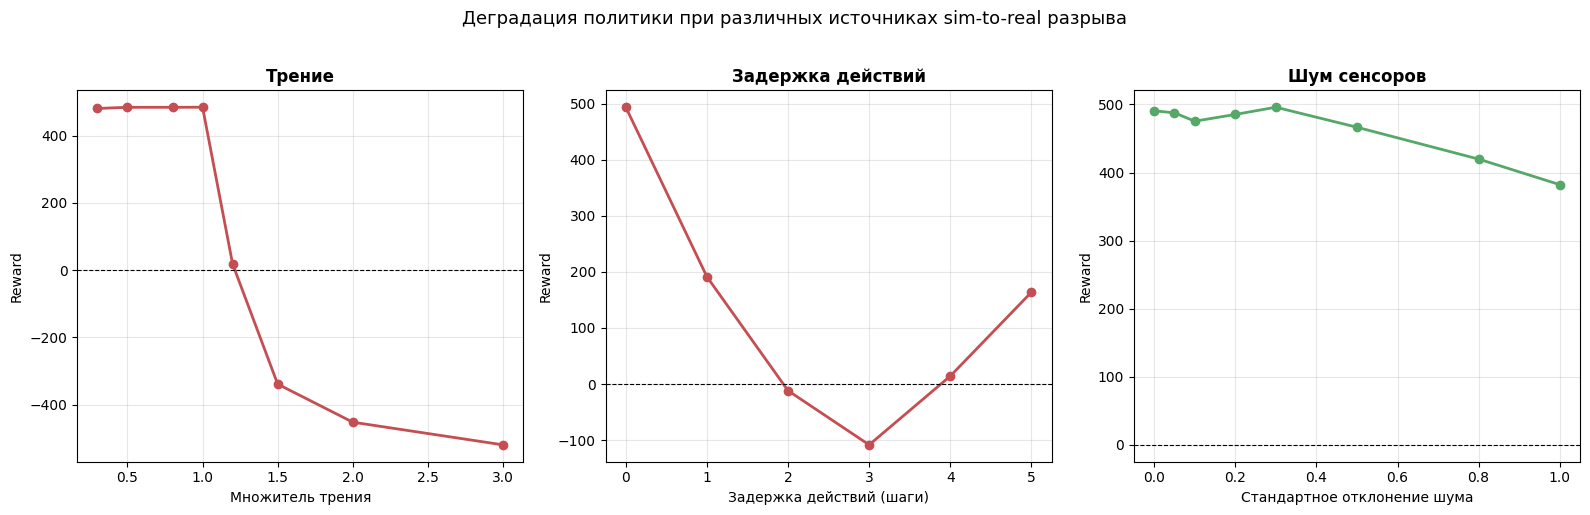

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

f_x = [r[0] for r in friction_results]
f_y = [r[1] for r in friction_results]
axes[0].plot(f_x, f_y, marker="o", linewidth=2, color="#C44E52")
axes[0].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Множитель трения")
axes[0].set_ylabel("Reward")
axes[0].set_title("Трение", fontweight="bold")
axes[0].grid(alpha=0.3)

d_x = [r[0] for r in delay_results]
d_y = [r[1] for r in delay_results]
axes[1].plot(d_x, d_y, marker="o", linewidth=2, color="#C44E52")
axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Задержка действий (шаги)")
axes[1].set_ylabel("Reward")
axes[1].set_title("Задержка действий", fontweight="bold")
axes[1].grid(alpha=0.3)

n_x = [r[0] for r in noise_results]
n_y = [r[1] for r in noise_results]
axes[2].plot(n_x, n_y, marker="o", linewidth=2, color="#55A868")
axes[2].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_xlabel("Стандартное отклонение шума")
axes[2].set_ylabel("Reward")
axes[2].set_title("Шум сенсоров", fontweight="bold")
axes[2].grid(alpha=0.3)

plt.suptitle("Деградация политики при различных источниках sim-to-real разрыва", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("sweep_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
with open("results.txt", "w") as f:
    f.write(f"Baseline: {mean_baseline:.2f} +/- {std_baseline:.2f}\n\n")
    f.write("=== Friction sweep ===\n")
    for value, mean_r, std_r in friction_results:
        f.write(f"{value}: {mean_r:.2f} +/- {std_r:.2f}\n")
    f.write("\n=== Delay sweep ===\n")
    for value, mean_r, std_r in delay_results:
        f.write(f"{value}: {mean_r:.2f} +/- {std_r:.2f}\n")
    f.write("\n=== Noise sweep ===\n")
    for value, mean_r, std_r in noise_results:
        f.write(f"{value}: {mean_r:.2f} +/- {std_r:.2f}\n")
print("Результаты сохранены")

Результаты сохранены
